In [1]:
cd ..

/Users/harini/Dropbox (MIT)/Harini Narayanan’s files/Home/CodonOptimization/Models/2Target_Pichia/BO_forHyperParameter


In [2]:
import math
import collections
import pickle
import random
%matplotlib inline
from matplotlib import pyplot as plt

import GPy
from GPy import likelihoods
import numpy as np
import pandas as pd
from tqdm import tqdm

# from Kernel import MixtureViaSumAndProduct, CategoryOverlapKernel
from InitialData_Gen import initialize

# from SamplingCategorical import compute_prob_dist_and_draw_hts
from UpdateCategoricalWeight import compute_reward_for_all_cat_variable, update_weights_for_all_cat_var

from AskTell import ask_tell

from scipy.optimize import minimize

from typing import Union, Tuple
from paramz.transformations import Logexp
import scipy
from scipy.optimize import minimize
from scipy.optimize import NonlinearConstraint



# np.random.seed(37)

In [3]:
bounds = [  {'name': 'Enc hidden size', 'type': 'continuous', 'domain': (60, 515)},
            {'name': 'Enc Embedding size', 'type': 'continuous', 'domain': (30, 260)},
         {'name': 'Dec Embedding size', 'type': 'continuous', 'domain': (30, 260)},
         {'name': 'Dense Layer size', 'type': 'continuous', 'domain': (30, 260)},
          {'name': 'Dense Layer size aa', 'type': 'continuous', 'domain': (30, 260)},
         {'name': 'Drop rate', 'type': 'continuous', 'domain': (0, 0.9)},
          {'name': 'Drop rate aa', 'type': 'continuous', 'domain': (0, 0.9)}]
    
Nx = len(bounds)
initN = 12
Niter = 1
batch_size = 3
approach_type = 'Co'
prob_type = 'UnConstrained'

data_param = {'Nx': Nx, 'nDim': Nx, 'bounds': bounds, 
              'approach_type': approach_type,
              'prob_type': prob_type, 'initN': initN}

In [4]:
runs0 = [0, 1, 2, 3, 4, 5, 6, 8, 9, 10 ,11]
data0 = pd.read_csv('./Arch1/InitialRound_HyperParameter.csv').iloc[runs0,1:].values
result0 = np.zeros((len(runs0), 1))

for i in range(len(runs0)):
    filename = '../EncDec_Arch1/Loss_Evolution/Initial/Combo' + str(runs0[i]) + '.csv'
    output = pd.read_csv(filename).iloc[:,1:].values
    result0[i] = output[-1,-2] *  output[-1,-1]
    
runs1 = [0, 1, 2]
data1 = pd.read_csv('./Arch1/Round1.csv').iloc[runs1,1:].values
result1 = np.zeros((len(runs1), 1))

for i in range(len(runs1)):
    filename = '../EncDec_Arch1/Loss_Evolution/Round1/Combo' + str(runs1[i]) + '.csv'
    output = pd.read_csv(filename).iloc[:,1:].values
    result1[i] = output[-1,-2] *  output[-1,-1]
    
runs2 = [0, 1, 2]
data2 = pd.read_csv('./Arch1/Round2.csv').iloc[runs2,1:].values
result2 = np.zeros((len(runs2), 1))

for i in range(len(runs1)):
    filename = '../EncDec_Arch1/Loss_Evolution/Round2/Combo' + str(runs2[i]) + '.csv'
    output = pd.read_csv(filename).iloc[:,1:].values
    result2[i] = output[-1,-2] *  output[-1,-1]
    
data = np.concatenate((data0, data1, data2), axis = 0)
result = np.concatenate((result0, result1, result2), axis = 0)

check2

Name : GP regression
Objective : 0.5797794946290544
Number of Parameters : 9
Number of Optimization Parameters : 9
Updates : True
Parameters:
  GP_regression.           |                   value  |  constraints  |  priors
  Mat32.variance           |      2.1842309806457982  |      +ve      |        
  Mat32.lengthscale        |                    (7,)  |      +ve      |        
  Gaussian_noise.variance  |  5.562684646268137e-309  |      +ve      |        
[[ 1.28340448 -0.70742419 -1.42650147 -1.08834746 -0.69405549  1.05827064
  -1.10875856]
 [ 1.30383763 -1.67526797  1.18295373 -0.2112278  -0.23402988 -0.98008599
   0.8677033 ]
 [ 1.04796284 -1.70966587 -1.67491027 -0.24704246  1.31172317  0.38782653
   1.30897359]]
(array([[1.09451611],
       [1.31356185],
       [1.29441204]]), array([[0.01066309],
       [0.01047945],
       [0.00980459]]))


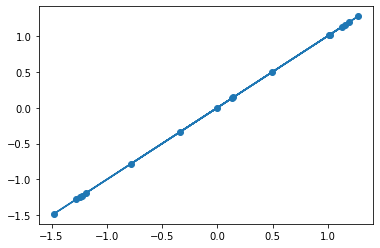

In [5]:
Wc_list = []
gamma_list = []
    
# for i in range(Niter):
X_exp, f_val, gp = ask_tell(data, result,data_param,
                        'Matern32', 'thompson_sampling', batch_size,  Wc_list, gamma_list) #thompson_sampling

X_ts_norm = (X_exp - np.mean(data, 0))/np.std(data, 0)
print(X_ts_norm)
Yp = gp.predict(X_ts_norm)
print(Yp)

In [6]:
column_names = []
for i in range(len(bounds)):
    column_names.append(data_param['bounds'][i]['name'])
    

X_exp[:,0:-2] = np.round(X_exp[:,0:-2])
X_exp[:,-2:] = np.round(X_exp[:,-2:],1)
X_exp_df = pd.DataFrame(X_exp)
X_exp_df.columns = column_names


pd.DataFrame(X_exp_df).to_csv('./Arch1/Round3.csv')

In [ ]:
column_names

In [7]:
X_exp_df

,Enc hidden size,Enc Embedding size,Dec Embedding size,Dense Layer size,Dense Layer size aa,Drop rate,Drop rate aa
0,506.0,100.0,59.0,55.0,109.0,0.7,0.1
1,510.0,42.0,224.0,125.0,139.0,0.0,0.7
2,468.0,40.0,43.0,122.0,240.0,0.5,0.8
